<a href="https://colab.research.google.com/github/vrajce/Aerial-View-Human-Action-Recognition/blob/main/AHAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#import statements
import os
import cv2
import numpy as np
from PIL import Image , ImageEnhance
from collections import defaultdict

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from genericpath import exists
# import dataset
train_path = '/content/drive/MyDrive/Aerial View Humain Action Detection/TrainSetVideos/Drone2'
output_path = '/content/drive/MyDrive/Aerial View Humain Action Detection/TrainSetVideos/Frames'   # place where frames will be stored
frame_quality = [cv2.IMWRITE_JPEG_QUALITY,95]

os.makedirs(output_path , exist_ok=True)  # make output folder

for time_of_day in ['Morning','Noon']:
  train_path_time_of_day = os.path.join(train_path,time_of_day)
  output_path_time_of_day = os.path.join(output_path,time_of_day)

  os.makedirs(output_path_time_of_day , exist_ok=True)   # making folders inside output according to time of the day

  for video in os.listdir(train_path_time_of_day):
    video_path = os.path.join(train_path_time_of_day,video)
    video_base = os.path.splitext(video)[0]

    output_video_path = os.path.join(output_path_time_of_day,video_base)
    os.makedirs(output_video_path,exist_ok=True)

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
      print(f"Error opening video file: {video_path}")
      exit()
    frame_idx = 0
    while True:
      ret , frame = cap.read()

      if not ret:
        break

      frame_filename = f"frame_{frame_idx:04d}.jpg"
      output_frame_path = os.path.join(output_video_path,frame_filename)

      cv2.imwrite(output_frame_path , frame , frame_quality)
      frame_idx+=1

    cap.release()
    print(f"Frames extracted from {video} and saved to {output_video_path}")



Frames extracted from 2.1.1.mp4 and saved to /content/drive/MyDrive/Aerial View Humain Action Detection/TrainSetVideos/Frames/Morning/2.1.1
Frames extracted from 2.1.10.mp4 and saved to /content/drive/MyDrive/Aerial View Humain Action Detection/TrainSetVideos/Frames/Morning/2.1.10
Frames extracted from 2.1.2.mp4 and saved to /content/drive/MyDrive/Aerial View Humain Action Detection/TrainSetVideos/Frames/Morning/2.1.2
Frames extracted from 2.1.3.mp4 and saved to /content/drive/MyDrive/Aerial View Humain Action Detection/TrainSetVideos/Frames/Morning/2.1.3
Frames extracted from 2.1.4.mp4 and saved to /content/drive/MyDrive/Aerial View Humain Action Detection/TrainSetVideos/Frames/Morning/2.1.4
Frames extracted from 2.1.5.mp4 and saved to /content/drive/MyDrive/Aerial View Humain Action Detection/TrainSetVideos/Frames/Morning/2.1.5
Frames extracted from 2.1.6.mp4 and saved to /content/drive/MyDrive/Aerial View Humain Action Detection/TrainSetVideos/Frames/Morning/2.1.6
Frames extracted f

In [ ]:
# frames are extracted and stored into folders based on time of day and video wise folders

In [ ]:
retained_dir = ["2.1.1"]    #sample

In [ ]:
# cv2 loads photo in BGR while PIL uses RGB convert image into RGB and also converting image into pil formatas cv2 load array
def simple_enhance(image):
  image_pil = Image.fromarray(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
  image_pil = ImageEnhance.Brightness(image_pil).enhance(1.05)      # increase the brightness by 5%
  image_pil = ImageEnhance.Contrast(image_pil).enhance(1.05)        # increase the contrast by 10%
  return cv2.cvtColor(np.array(image_pil),cv2.COLOR_RGB2BGR)

def process_okutama_dataset(image_dir,output_dir,label_dir,padding=0.15):
  os.makedirs(output_dir,exist_ok=True)

  generated_dict = defaultdict(int)

  for time_of_day in ['Morning', 'Noon']:
    time_of_day_dir = os.path.join(image_dir , time_of_day)
    for video_folder in sorted(os.listdir(time_of_day_dir)):

      if video_folder not in retained_dir:
        continue

      # we will process the frames means cropping and saving related to action
      label_path = os.path.join(label_dir,f"{video_folder}.txt")
      if not os.path.exists(label_path):
        print(f"Label file missing for {video_folder} video")
        continue


      video_folder_path = os.path.join(time_of_day_dir,video_folder)



      with open(label_path , 'r') as label_file:
        lines = label_file.readlines()

        for line in lines:
          parts = line.strip().split()

          if len(parts) < 11:
            continue

          try:
            track_id = int(parts[0])
            x1,y1,x2,y2 = map(int,parts[1:5])
            frame_id = int(parts[5])
            lost = int(parts[6])
            occlued = int(parts[7])
            generated = int(parts[8])
            if lost==1 : continue
            if generated == 1:
              generated_dict[(video_folder,track_id)]+=1
              if generated_dict[(video_folder,track_id)]%5!=0:
                continue
            label = parts[9]
            actions = [a.strip('"').lower() for a in parts[10:]]
            if not actions : continue
          except ValueError:
            continue


        ## calculating height and width of person
          height = y2-y1
          width = x2-x1

        # applying padding , so that box is not that tight and person is no cropped

          x1_pad = max(0,int(x1-(width*padding)))
          y1_pad = max(0,int(y1-(height*padding)))
          x2_pad = min(3829 , int(x2+(width*padding)))
          y2_pad = min(2159 , int(y2+(height*padding)))

          frame_filename = f"frame_{frame_id:04d}.jpg"
          frame_path = os.path.join(video_folder_path,frame_filename)

          frame = cv2.imread(frame_path)
          if frame is None: continue

          cropped = frame[y1_pad:y2_pad,x1_pad:x2_pad]
          cropped = cv2.resize(cropped , (224,224) , interpolation=cv2.INTER_AREA)

          crop = simple_enhance(cropped)

          action_names = "_".join(actions)

          save_path = os.path.join(output_dir , video_folder , f"person_{track_id}" , action_names)
          os.makedirs(save_path , exist_ok=True)
          frame_save_path = os.path.join(save_path , f"{frame_filename}")
          cv2.imwrite(frame_save_path , crop)



In [ ]:
image_dir = '/content/drive/MyDrive/Aerial View Humain Action Detection/TrainSetVideos/Frames'
output_dir = '/content/drive/MyDrive/Aerial View Humain Action Detection/TrainSetVideos/cropped_okutama'
label_dir = '/content/drive/MyDrive/Aerial View Humain Action Detection/TrainSetVideos/Labels/MultiActionLabels/3840x2160'

In [ ]:
process_okutama_dataset(image_dir , output_dir , label_dir)

In [ ]:
for video_f in os.listdir(output_dir):
  person_folders = os.path.join(output_dir,video_f)
  for person_f in os.listdir(person_folders):
    count = 0
    for action_f in os.listdir(os.path.join(person_folders,person_f)):
      count+=len(os.listdir(os.path.join(person_folders,person_f,action_f)))
      print(f"{person_f} {action_f} has {count} images")


person_0 standing_carrying has 25 images
person_0 walking_carrying has 51 images
person_1 lying has 51 images
person_2 sitting has 51 images
person_3 sitting_reading has 51 images
person_4 standing has 51 images
person_5 standing has 51 images
person_6 standing_reading has 51 images
person_7 walking has 11 images
person_8 walking has 16 images
person_9 standing_carrying has 51 images
person_10 standing_carrying has 51 images
person_11 standing has 25 images
person_11 running has 51 images
person_12 lying has 5 images
person_13 walking_carrying has 30 images
person_14 standing has 14 images
person_14 standing_hand_shaking has 50 images
person_15 standing has 14 images
person_15 standing_hand_shaking has 50 images
person_16 running has 50 images
person_17 standing has 50 images
person_18 standing_carrying has 50 images
person_19 standing_carrying has 50 images
person_20 walking has 47 images
person_20 standing has 50 images
person_21 walking has 16 images
person_21 standing_reading has 2

In [ ]:
# next phase
# for now it is done for 1 video only but we will do for all the videos available!


Scanning /content/drive/MyDrive/Aerial View Humain Action Detection/TrainSetVideos/cropped_okutama for 50-frame sequences...

FINAL REPORT
Total Action Clips Found: 102
✅ Valid (>= 50 frames): 33
⚠️ Short (< 50 frames):  69
Success Rate: 32.4%


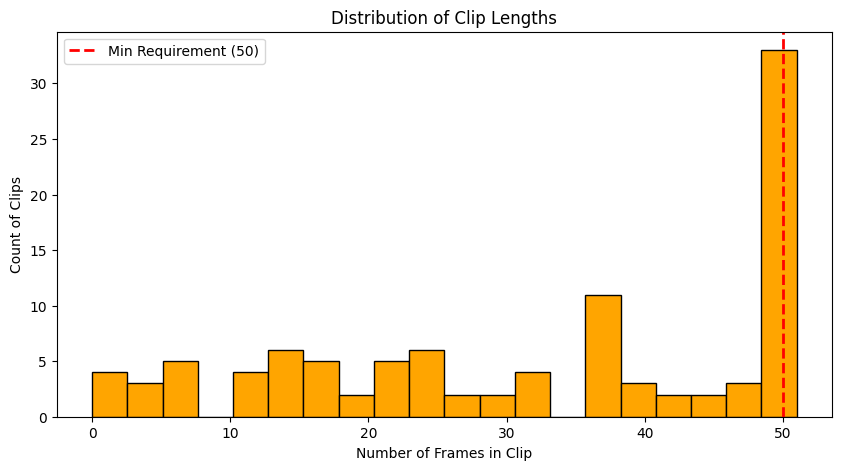

In [4]:
import os
import matplotlib.pyplot as plt

# 1. SETUP
# This must match the 'output_dir' from your previous code
DATASET_PATH = '/content/drive/MyDrive/Aerial View Humain Action Detection/TrainSetVideos/cropped_okutama'
REQUIRED_SEQ_LEN = 50

# 2. SCANNERS
total_clips = 0
valid_clips = 0  # Clips with >= 50 frames
short_clips = 0  # Clips with < 50 frames
frame_counts = []

print(f"Scanning {DATASET_PATH} for {REQUIRED_SEQ_LEN}-frame sequences...")

if not os.path.exists(DATASET_PATH):
    print("Error: The folder path does not exist. Check your Drive mounting.")
else:
    # Loop through all videos (e.g., "2.1.1")
    for video_folder in os.listdir(DATASET_PATH):
        video_path = os.path.join(DATASET_PATH, video_folder)
        if not os.path.isdir(video_path): continue

        # Loop through all persons (e.g., "person_0")
        for person_id in os.listdir(video_path):
            person_path = os.path.join(video_path, person_id)
            if not os.path.isdir(person_path): continue

            # Loop through all actions (e.g., "standing_carrying")
            for action_folder in os.listdir(person_path):
                action_path = os.path.join(person_path, action_folder)

                # Count the images
                frames = [f for f in os.listdir(action_path) if f.endswith('.jpg')]
                count = len(frames)

                # Record stats
                total_clips += 1
                frame_counts.append(count)

                if count >= REQUIRED_SEQ_LEN:
                    valid_clips += 1
                else:
                    short_clips += 1
                    # Optional: Print the first few short ones to see what's happening
                    if short_clips <= 5:
                        print(f"  Warning: Short clip found! {video_folder}/{person_id}/{action_folder} has only {count} frames.")

    # 3. REPORT
    print("\n" + "="*40)
    print(f"FINAL REPORT")
    print("="*40)
    print(f"Total Action Clips Found: {total_clips}")
    print(f"✅ Valid (>= 50 frames): {valid_clips}")
    print(f"⚠️ Short (< 50 frames):  {short_clips}")

    if total_clips > 0:
        print(f"Success Rate: {(valid_clips/total_clips)*100:.1f}%")

    # 4. VISUALIZATION
    plt.figure(figsize=(10, 5))
    plt.hist(frame_counts, bins=20, color='orange', edgecolor='black')
    plt.axvline(REQUIRED_SEQ_LEN, color='red', linestyle='dashed', linewidth=2, label=f'Min Requirement ({REQUIRED_SEQ_LEN})')
    plt.title("Distribution of Clip Lengths")
    plt.xlabel("Number of Frames in Clip")
    plt.ylabel("Count of Clips")
    plt.legend()
    plt.show()